In [1]:
import sys
from pathlib import Path

# go to project root (notebooks -> parent)
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [8]:
import joblib
import shap 
from src import load_raw_data

import matplotlib.pyplot as plt
from pathlib import Path



model = joblib.load("../models/best_model.pkl")
df = load_raw_data()
X= df.drop('loan_status', axis=1)
y= df['loan_status']

In [27]:
X_sample = X.sample(2000, random_state=42)

explainer = shap.TreeExplainer(model.named_steps['clf'])
X_transformed = model.named_steps['preprocess'].transform(X_sample)
feature_names = model.named_steps['preprocess'].get_feature_names_out()
shap_values = explainer.shap_values(X_transformed)

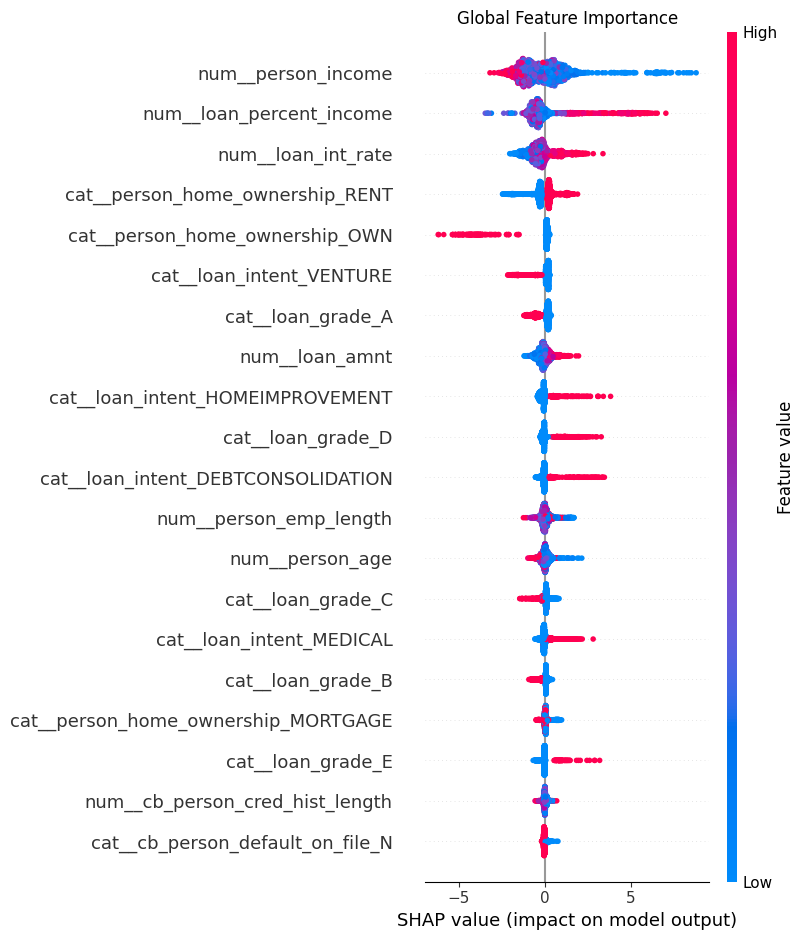

In [28]:
Path("../figures").mkdir(exist_ok=True)

plt.title("Global Feature Importance")
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, show=False)

plt.savefig("../figures/global_importance.png", dpi=300, bbox_inches='tight')
plt.show()


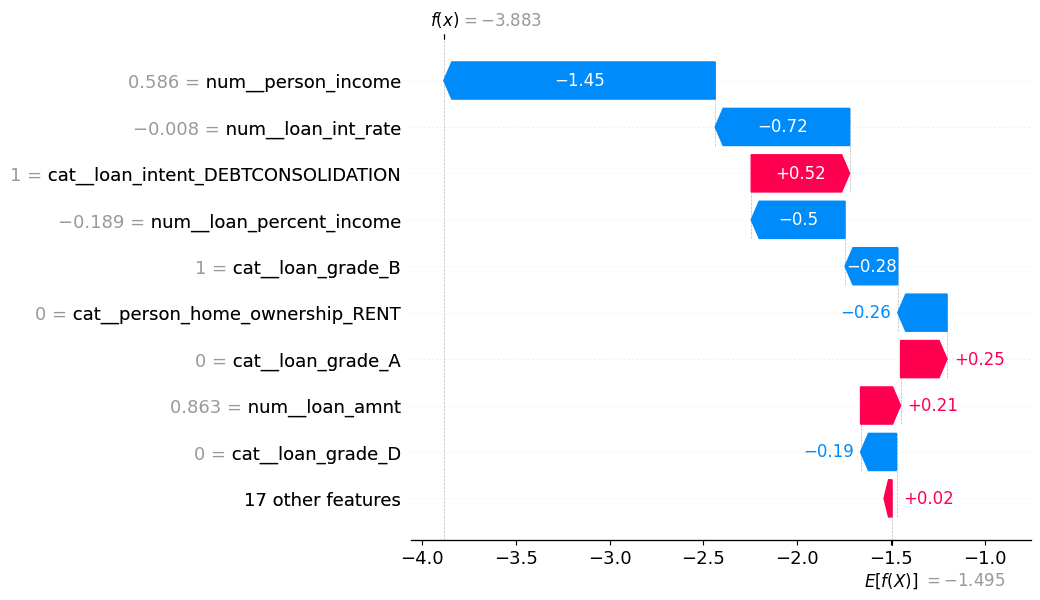

In [30]:
row = X_sample.iloc[[50]]
row_t = model.named_steps['preprocess'].transform(row)
feature_names = model.named_steps['preprocess'].get_feature_names_out()

shap_value = explainer(row_t)
shap_value.feature_names = feature_names
shap.plots.waterfall(shap_value[0])
# plt.savefig("../figures/local_importance.png", dpi=300, bbox_inches='tight')
plt.show()